# Assignment 5: feature ranking 

## Due on Wed 18th March at 12pm
### Submit your jupyter notebook on QMPlus (tab Assessments) with name LAST_NAME_Assignment_5.ipynb

## Task: in this assignment you need to discover the functional dependence between the target y and the inputs x_0, ... x_7 in the dataset "data_assignment_5.csv"


###  The target y is a linear combination of features:

\begin{equation}
 y = \sum_i \alpha_i f_i(x_i)
\end{equation}

## Subtask 1: Understand inter-dependencies between features

Use this section to explore how the input features relate to each other. Typical checks include summary statistics, a correlation matrix, pairwise plots, or any other diagnostic that helps you identify dependencies between the features.

,x0,x1,x2,x3,x4,x5,x6,x7,y
0,0.561055,0.079270,0.314782,-0.783157,-0.577937,0.340844,0.472646,0.623351,0.084778
1,0.008566,0.875069,0.000073,-0.163259,-4.759981,0.398928,0.815880,0.442250,-2.084777
2,0.517907,0.846202,0.268228,1.301721,-0.657960,0.348871,0.208570,0.811745,2.477395
3,0.265400,0.499013,0.070437,-0.226884,-1.326518,0.385137,0.009121,0.990921,-2.203207
4,0.468041,0.864435,0.219063,2.702967,-0.759198,0.357554,0.301334,0.739830,3.951236


,x0,x1,x2,x3,x4,x5,x6,x7,y
count,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.496408,0.496902,3.303143e-01,-0.004095,-1.017076,0.341871,0.504629,0.629020,-0.131219
std,0.289659,0.289207,2.988347e-01,0.999558,1.022725,0.048498,0.287478,0.179751,2.342276
min,0.000123,0.000011,1.514482e-08,-3.376723,-9.002804,0.241977,0.000037,0.368041,-17.014665
25%,0.245633,0.242787,6.033576e-02,-0.664858,-1.403915,0.302287,0.259184,0.470558,-1.241116
50%,0.496453,0.492571,2.464652e-01,0.000358,-0.700267,0.352688,0.508069,0.601656,0.282847
75%,0.744903,0.749046,5.548804e-01,0.684682,-0.294501,0.387087,0.753835,0.771681,1.477248
max,0.999973,0.999944,9.999455e-01,4.155836,-0.000027,0.398942,0.999562,0.999963,5.165316


,x0,x1,x2,x3,x4,x5,x6,x7,y
x0,1.000000,-0.001496,0.967593,0.002188,0.861168,-0.979792,-0.009587,0.010634,0.108748
x1,-0.001496,1.000000,0.000340,0.008816,-0.001946,-0.000408,-0.001339,0.001617,0.241897
x2,0.967593,0.000340,1.000000,0.005609,0.738143,-0.997978,-0.005485,0.006306,0.104665
x3,0.002188,0.008816,0.005609,1.000000,0.003450,-0.004639,0.008990,-0.008710,-0.007131
x4,0.861168,-0.001946,0.738143,0.003450,1.000000,-0.762894,-0.014439,0.015409,0.098614
x5,-0.979792,-0.000408,-0.997978,-0.004639,-0.762894,1.000000,0.006757,-0.007642,-0.106197
x6,-0.009587,-0.001339,-0.005485,0.008990,-0.014439,0.006757,1.000000,-0.991790,0.010071
x7,0.010634,0.001617,0.006306,-0.008710,0.015409,-0.007642,-0.991790,1.000000,-0.011382
y,0.108748,0.241897,0.104665,-0.007131,0.098614,-0.106197,0.010071,-0.011382,1.000000


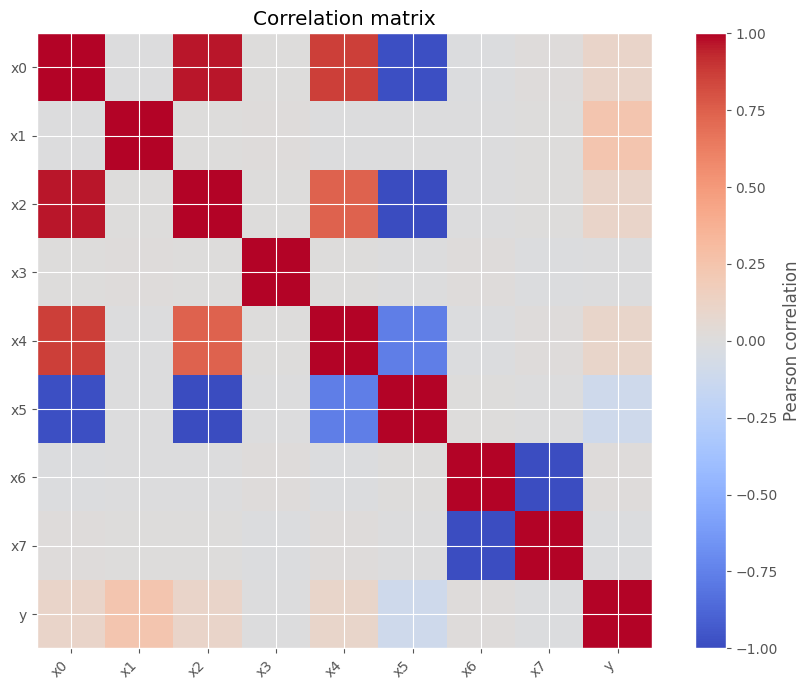

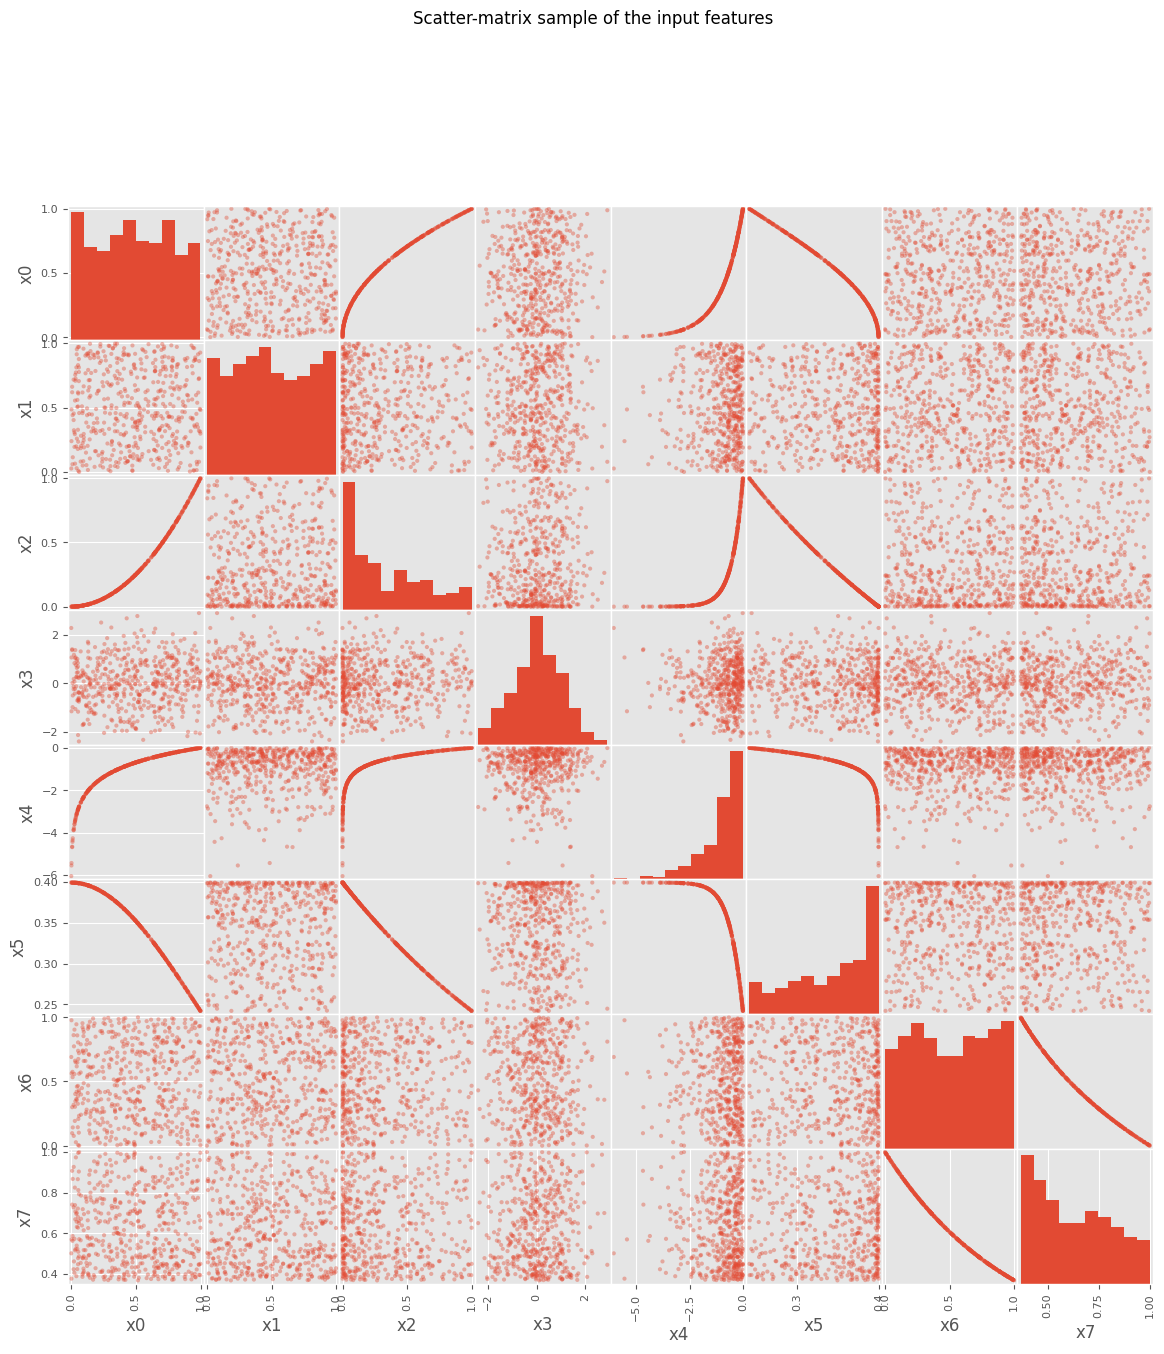

Absolute correlation ranking against y:


,corr_with_y
x1,0.241897
x0,0.108748
x5,-0.106197
x2,0.104665
x4,0.098614
x7,-0.011382
x6,0.010071
x3,-0.007131


Train shape: (8000, 8), Test shape: (2000, 8)
Target mean/std used for scaling: -0.1303, 2.3499


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

#Set seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.style.use("ggplot")

# Load and map data
df = pd.read_csv("data/data_assignment_5.csv")
feature_cols = [f"x{i}" for i in range(8)]
target_col = "y"

#Display data and correlation
print("Dataset head:")
display(df.head())
print("\nDataset description:")
display(df[feature_cols + [target_col]].describe())
correlation_matrix = df[feature_cols + [target_col]].corr(numeric_only=True)
print("\nCorrelation matrix:")
display(correlation_matrix)

#Plot correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Correlation matrix")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

#Plot scatter matrix
sample_df = df[feature_cols].sample(n=500, random_state=SEED)
pd.plotting.scatter_matrix(sample_df, figsize=(14, 14), diagonal="hist", alpha=0.4)
plt.suptitle("Scatter-matrix sample of the input features", y=1.02)
plt.show()

#Rank features by absolute correlation with target
feature_target_corr = correlation_matrix["y"].drop("y").sort_values(key=np.abs, ascending=False)
print("Absolute correlation ranking against y:")
display(feature_target_corr.to_frame(name="corr_with_y"))

#Split dataset
x = df[feature_cols].copy()
y = df[target_col].to_numpy(dtype=np.float32)

x_train_df, x_test_df, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=SEED,
)

# Standardize features and target using training data statistics
feature_mean = x_train_df.mean().to_numpy(dtype=np.float32)
feature_std = x_train_df.std(ddof=0).replace(0, 1).to_numpy(dtype=np.float32)

x_train = ((x_train_df.to_numpy(dtype=np.float32) - feature_mean) / feature_std).astype(np.float32)
x_test = ((x_test_df.to_numpy(dtype=np.float32) - feature_mean) / feature_std).astype(np.float32)

#Calculate target mean and std for scaling, ensuring std is not zero
target_mean = float(y_train.mean())
target_std = float(y_train.std()) if float(y_train.std()) > 0 else 1.0
y_train_scaled = ((y_train - target_mean) / target_std).astype(np.float32)
y_test_scaled = ((y_test - target_mean) / target_std).astype(np.float32)

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")
print(f"Target mean/std used for scaling: {target_mean:.4f}, {target_std:.4f}")


## Subtask 2: Develop a Neural Additive Model (NAM)

Build a NAM to learn the functional dependence between $y$ and each feature $x_i$. The model should represent the target as an additive sum of learned one-dimensional feature functions.

,loss,rmse,val_loss,val_rmse
144,0.004109,0.064098,0.001482,0.038503
145,0.004018,0.063390,0.001029,0.032085
146,0.003957,0.062903,0.002922,0.054057
147,0.005952,0.077151,0.001612,0.040151
148,0.004076,0.063842,0.001728,0.041574


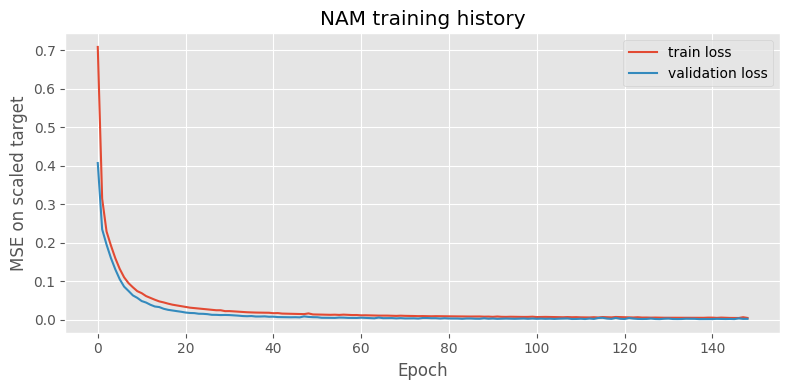

Feature ranking from the NAM:


,mean_abs_contribution
x3,1.689464
x1,0.533254
x2,0.107073
x7,0.096116
x6,0.095473
x5,0.072084
x4,0.055874
x0,0.031714


Learned baseline contribution in y-units: -0.1311


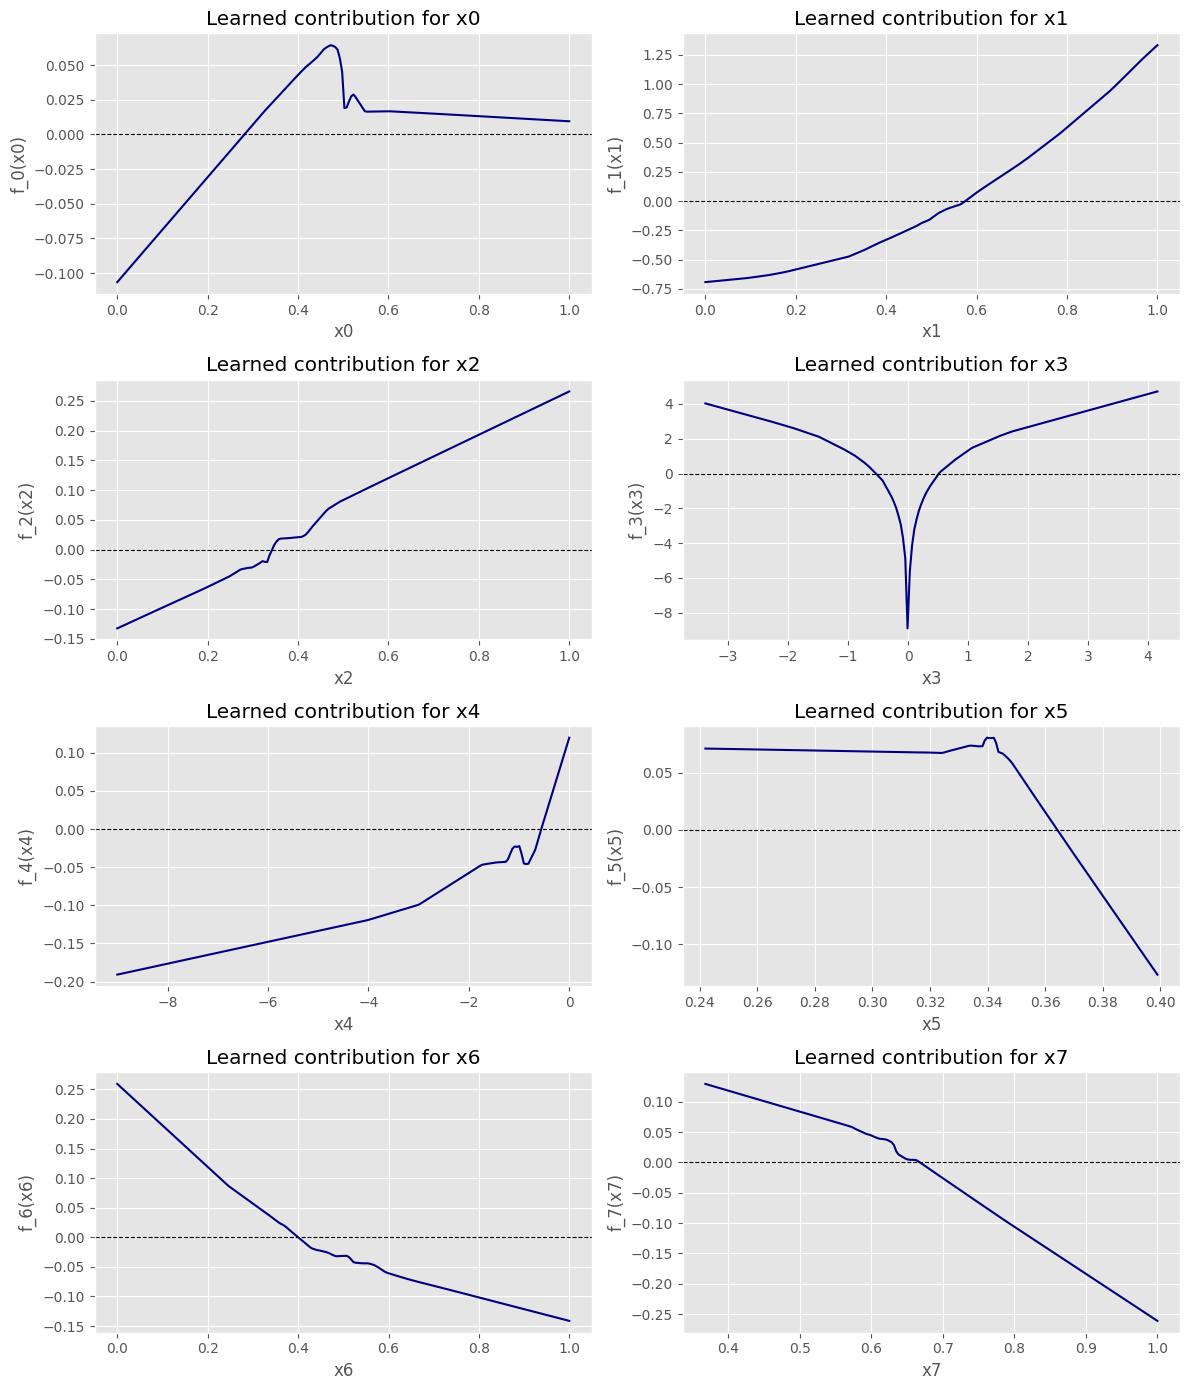

In [ ]:
# Define the feature network for each input feature
class FeatureNetwork(tf.keras.layers.Layer):
    def __init__(self, hidden_units=(64, 32), name=None):
        super().__init__(name=name)
        self.hidden_layers = [
            tf.keras.layers.Dense(units, activation="relu")
            for units in hidden_units
        ]
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs, training=False):
        x = tf.expand_dims(inputs, axis=-1)
        for layer in self.hidden_layers:
            x = layer(x, training=training)
        return self.output_layer(x)

# Define the overall NAM model
class NeuralAdditiveModel(tf.keras.Model):
    def __init__(self, num_features, hidden_units=(64, 32)):
        super().__init__()
        self.feature_nets = [
            FeatureNetwork(hidden_units=hidden_units, name=f"feature_net_{i}")
            for i in range(num_features)
        ]
        self.bias_term = self.add_weight(
            name="global_bias",
            shape=(),
            initializer="zeros",
            trainable=True,
        )

    # The call method computes the output of each feature network and sums them with the bias term
    def call(self, inputs, training=False, return_terms=False):
        terms = []
        for i, net in enumerate(self.feature_nets):
            term = tf.squeeze(net(inputs[:, i], training=training), axis=-1)
            terms.append(term)
        stacked_terms = tf.stack(terms, axis=1)
        prediction = tf.reduce_sum(stacked_terms, axis=1) + self.bias_term
        if return_terms:
            return prediction, stacked_terms
        return prediction

#Set up batch size and datasets for training
batch_size = 256
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_scaled))
train_ds = train_ds.shuffle(len(x_train), seed=SEED).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_scaled)).batch(batch_size)

# Initialize,compile and fit the NAM model
nam = NeuralAdditiveModel(num_features=len(feature_cols), hidden_units=(64, 32))
nam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
    )
]

history = nam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    verbose=0,
    callbacks=callbacks,
)

history_df = pd.DataFrame(history.history)
print("Training history (last 5 epochs):")
display(history_df.tail())

# Plot training and validation history
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["val_loss"], label="validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE on scaled target")
ax.set_title("NAM training history")
ax.legend()
plt.tight_layout()
plt.show()

# Analyze learned feature contributions and importance
train_pred_scaled, train_terms = nam(x_train, return_terms=True)
test_pred_scaled, test_terms = nam(x_test, return_terms=True)

# Convert tensors to numpy arrays and compute centered contributions
train_pred_scaled = train_pred_scaled.numpy().squeeze()
test_pred_scaled = test_pred_scaled.numpy().squeeze()
train_terms = train_terms.numpy()
test_terms = test_terms.numpy()

# Compute mean contribution of each feature across training data to center the learned functions
term_offsets = train_terms.mean(axis=0)
centered_train_terms = (train_terms - term_offsets) * target_std
centered_test_terms = (test_terms - term_offsets) * target_std

# Convert scaled predictions back to original target units
train_pred = target_mean + target_std * train_pred_scaled
test_pred = target_mean + target_std * test_pred_scaled
base_offset = target_mean + target_std * (float(nam.bias_term.numpy()) + float(term_offsets.sum()))

# Compute and print feature importance as mean absolute contribution across test samples
feature_importance = pd.Series(
    np.mean(np.abs(centered_test_terms), axis=0),
    index=feature_cols,
    name="mean_abs_contribution",
).sort_values(ascending=False)
print("Feature ranking from the NAM:")
display(feature_importance.to_frame())
print(f"Learned baseline contribution in y-units: {base_offset:.4f}")

#Plot learned feature contributions as functions of each input feature
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for i, col in enumerate(feature_cols):
    ax = axes.flat[i]
    raw_grid = np.linspace(df[col].min(), df[col].max(), 200, dtype=np.float32)
    scaled_grid = (raw_grid - feature_mean[i]) / feature_std[i]
    learned_function = nam.feature_nets[i](tf.convert_to_tensor(scaled_grid)).numpy().squeeze()
    centered_function = (learned_function - term_offsets[i]) * target_std
    ax.plot(raw_grid, centered_function, color="navy")
    ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Learned contribution for {col}")
    ax.set_xlabel(col)
    ax.set_ylabel(f"f_{i}({col})")
plt.tight_layout()
plt.show()


## Subtask 3: Validate the learned formula

Evaluate the model by calculating the RMSE and plotting predicted values against the ground-truth target values. Use this section to show whether the learned additive formula matches the data well.

Train RMSE: 0.1626
Test RMSE: 0.0746


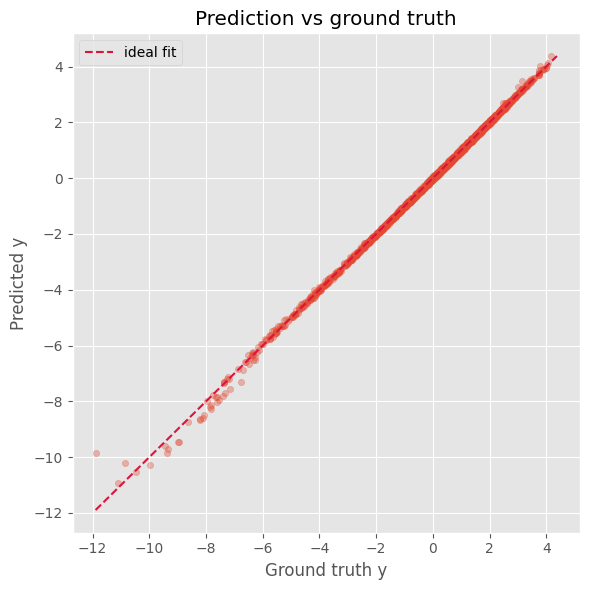

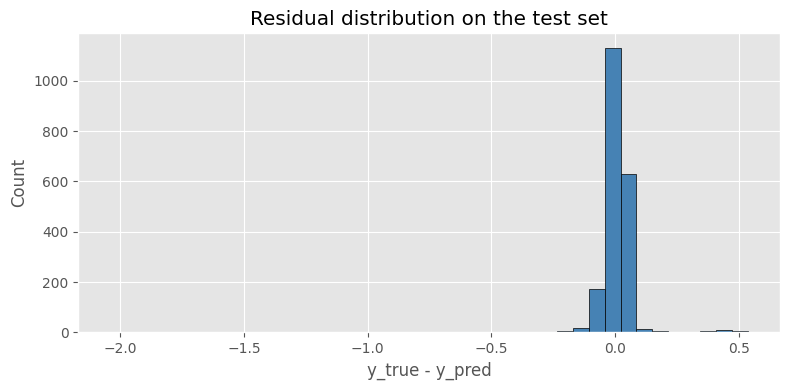

,y_true,y_pred,residual
0,0.743936,0.696989,0.046947
1,0.584655,0.546090,0.038566
2,4.047209,4.113687,-0.066477
3,-0.177246,-0.187337,0.010092
4,1.829589,1.855275,-0.025686
5,-1.384538,-1.395314,0.010776
6,3.080449,3.081410,-0.000961
7,-2.803158,-2.822961,0.019803
8,-2.209259,-2.228770,0.019512
9,0.304059,0.291938,0.012120


In [ ]:
#Calculate and print RMSE on train and test sets
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

#Plot predicted vs true values and residual distribution
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, test_pred, alpha=0.35, s=20)
line_min = min(y_test.min(), test_pred.min())
line_max = max(y_test.max(), test_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], color="crimson", linestyle="--", label="ideal fit")
ax.set_xlabel("Ground truth y")
ax.set_ylabel("Predicted y")
ax.set_title("Prediction vs ground truth")
ax.legend()
plt.tight_layout()
plt.show()

#Plot residual distribution histogram
residuals = y_test - test_pred
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=40, color="steelblue", edgecolor="black")
ax.set_title("Residual distribution on the test set")
ax.set_xlabel("y_true - y_pred")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

#Create a dataframe with true values, predictions and residuals and print the first 10 test samples
results_df = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": test_pred,
        "residual": residuals,
    }
)
display(results_df.head(10))
